In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.stats import poisson
from scipy.stats import binom
from scipy import stats

In [5]:
mu = 72
sigma = 12

prob_a = norm.cdf(84, mu, sigma) - norm.cdf(60, mu, sigma)

print(prob_a)
print(f"Foizda: {prob_a * 100:.2f}%")

0.6826894921370859
Foizda: 68.27%


In [7]:
prob_b = 1 - norm.cdf(90, mu, sigma)

print(prob_b)
print(f"Foizda: {prob_b * 100:.2f}%")

0.06680720126885809
Foizda: 6.68%


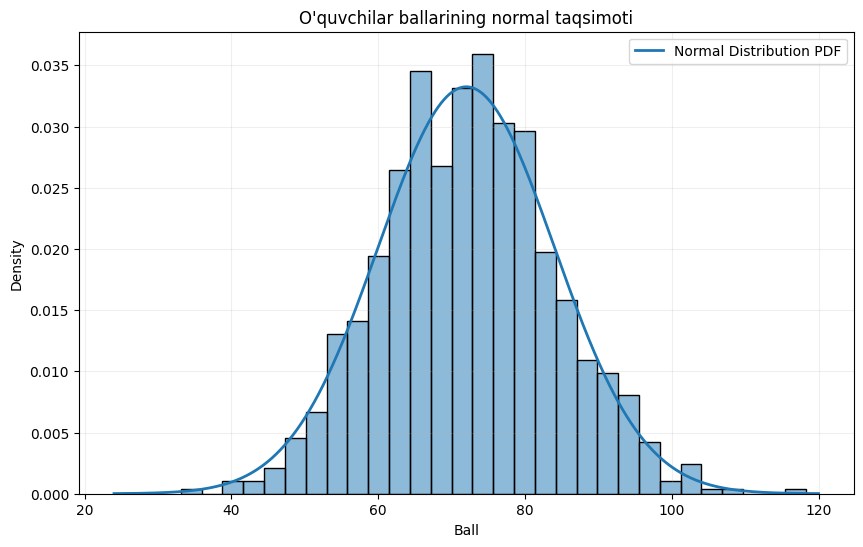

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

mu = 72
sigma = 12

np.random.seed(42)
scores = np.random.normal(mu, sigma, 1000)

plt.figure(figsize=(10, 6))

sns.histplot(
    scores,
    bins=30,
    stat="density",
    kde=False,
    alpha=0.5
)

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

pdf = norm.pdf(x, mu, sigma)

plt.plot(
    x,
    pdf,
    linewidth=2,
    label="Normal Distribution PDF"
)

plt.xlabel("Ball")
plt.ylabel("Density")
plt.title("O'quvchilar ballarining normal taqsimoti")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [13]:
lambda_ = 8

prob_a = poisson.pmf(10, lambda_)

print(prob_a)
print(f"Foizda: {prob_a * 100:.2f}%")

0.09926153383153544
Foizda: 9.93%


In [15]:
prob_b = 1 - poisson.cdf(15, lambda_)

print(prob_b)
print(f"Foizda: {prob_b * 100:.2f}%")

0.008231010986844867
Foizda: 0.82%


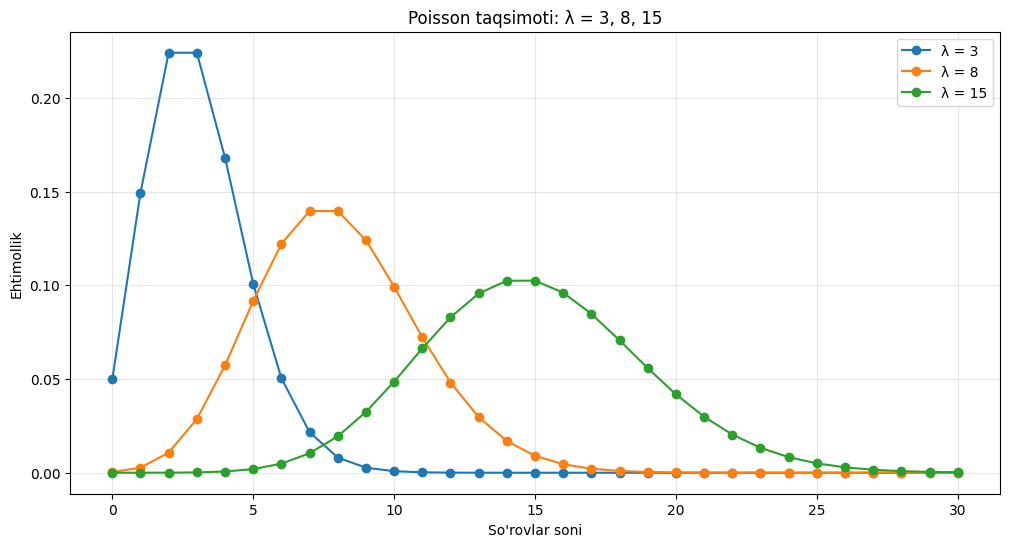

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

lambdas = [3, 8, 15]

x = np.arange(0, 31)

plt.figure(figsize=(12, 6))

for lam in lambdas:
    probabilities = poisson.pmf(x, lam)

    plt.plot(
        x,
        probabilities,
        marker='o',
        label=f"λ = {lam}"
    )

plt.xlabel("So'rovlar soni")
plt.ylabel("Ehtimollik")
plt.title("Poisson taqsimoti: λ = 3, 8, 15")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [19]:
n = 100
p = 0.35

prob_a = binom.pmf(30, n, p)

print(prob_a)
print(f"Foizda: {prob_a * 100:.2f}%")

0.049421376758864016
Foizda: 4.94%


In [20]:
prob_b = 1 - binom.cdf(50, n, p)

print(prob_b)
print(f"Foizda: {prob_b * 100:.4f}%")

0.0007378332488625627
Foizda: 0.0738%


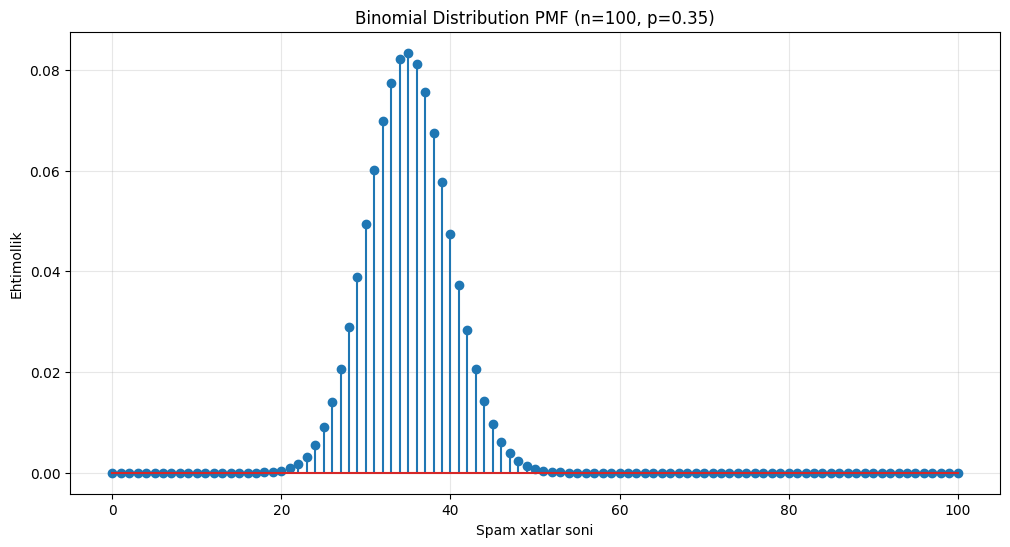

In [21]:
x = np.arange(0, 101)

pmf = binom.pmf(x, n, p)

plt.figure(figsize=(12, 6))

plt.stem(x, pmf)

plt.xlabel("Spam xatlar soni")
plt.ylabel("Ehtimollik")
plt.title("Binomial Distribution PMF (n=100, p=0.35)")

plt.grid(alpha=0.3)

plt.show()

In [24]:
import pandas as pd
df = pd.read_csv("clean_dataset.csv")
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


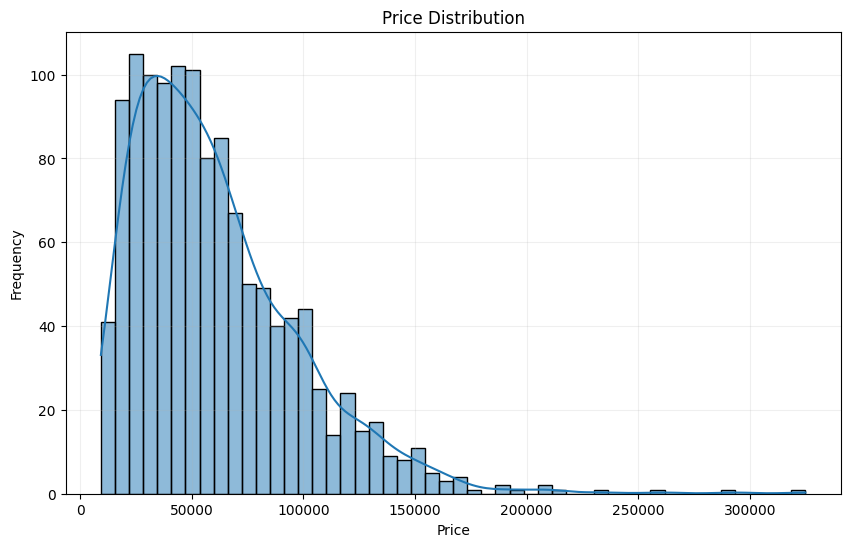

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Price"],
    bins=50,
    kde=True
)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.grid(alpha=0.2)
plt.show()

In [31]:
df["Price_log"] = np.log1p(df["Price"])

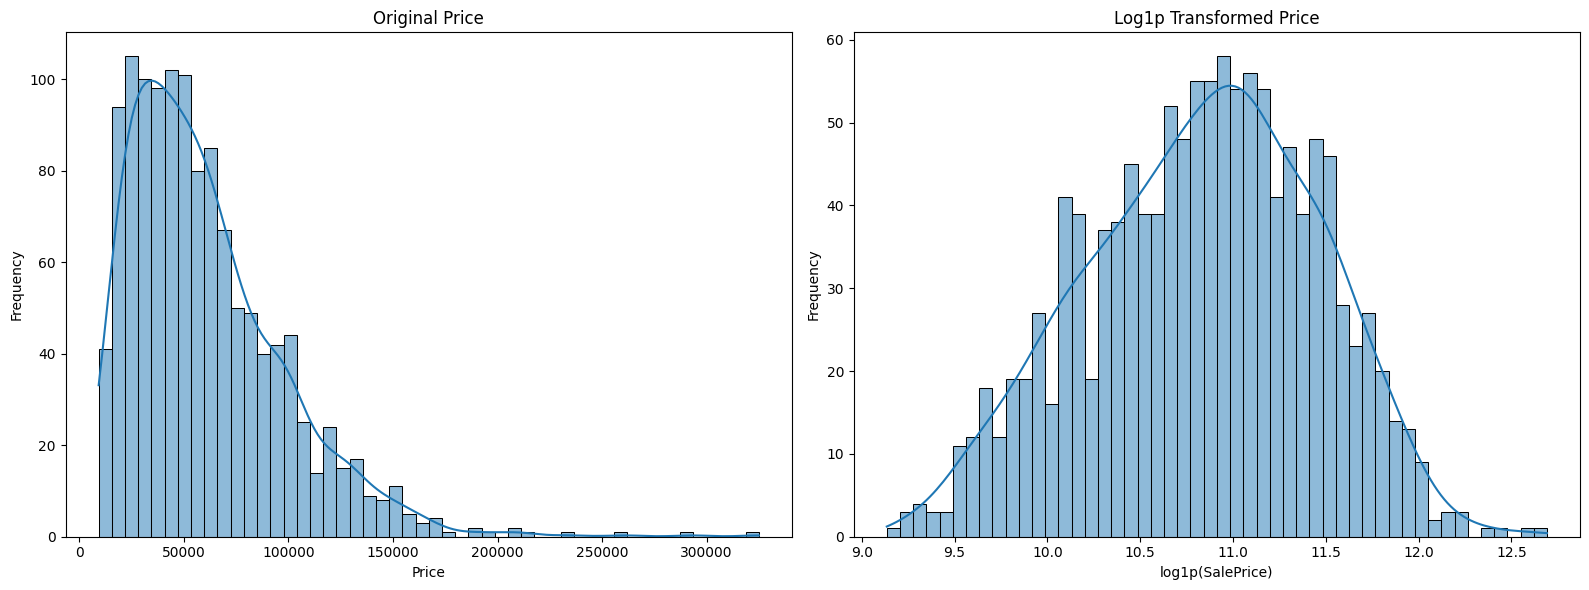

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original SalePrice
sns.histplot(
    df["Price"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original Price")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")

# Log transform
sns.histplot(
    df["Price_log"],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Log1p Transformed Price")
axes[1].set_xlabel("log1p(SalePrice)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

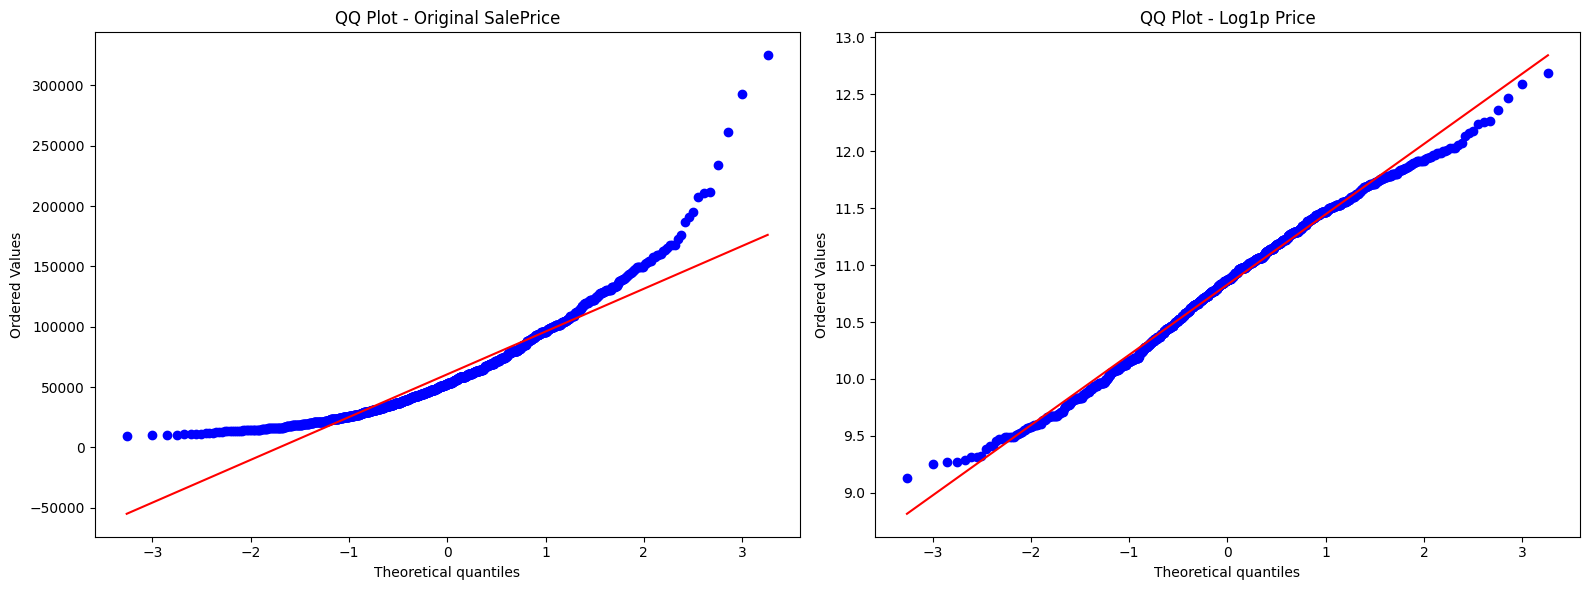

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

stats.probplot(
    df["Price"],
    dist="norm",
    plot=axes[0]
)

axes[0].set_title("QQ Plot - Original SalePrice")

stats.probplot(
    df["Price_log"],
    dist="norm",
    plot=axes[1]
)

axes[1].set_title("QQ Plot - Log1p Price")

plt.tight_layout()
plt.show()